# Multiple Linear Regression + Feature Scaling

**Predicting student final grade `G3` from several features at once.**

This is the multi-feature sibling of `student-result-prediction.ipynb`.

In the single-feature notebook the model was:

$$f_{w,b}(x) = w\,x + b$$

Now we have `n` features, so `w` becomes a **vector** and we use a dot product (this is exactly Andrew Ng Course 1, Week 2):

$$f_{\vec{w},b}(\vec{x}) = \vec{w}\cdot\vec{x} + b = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$$

Two new ideas vs. the single-feature notebook:
1. **Vectorization** — using `np.dot` / matrix math instead of looping over features.
2. **Feature scaling (z-score normalization)** — because features live on very different ranges (e.g. `age` 15-22 vs `studytime` 1-4), gradient descent converges much faster when every feature is on a comparable scale.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Same dataset as the single-feature notebook
# df = pd.read_csv("./student-por.csv")
df = pd.read_csv("https://raw.githubusercontent.com/naimdotcom/ML-everything/main/Student-score-result/student-por.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 1. Pick multiple features

Instead of just `absences`, we feed the model several numeric columns. These are all plausibly related to the final grade `G3`:

| feature | meaning |
|---|---|
| `G1` | first period grade |
| `G2` | second period grade |
| `studytime` | weekly study time (1-4) |
| `failures` | number of past class failures |
| `absences` | number of school absences |
| `age` | student's age |
| `Medu` | mother's education (0-4) |
| `Fedu` | father's education (0-4) |

Notice the ranges are wildly different — that is exactly why we need feature scaling.

In [3]:
feature_cols = ["G1", "G2", "studytime", "failures", "absences", "age", "Medu", "Fedu"]
target_col = "G3"

# Some columns in this CSV are read as strings (quoted numbers), so force numeric
X = df[feature_cols].apply(pd.to_numeric, errors="coerce").values  # shape (m, n)
y = df[target_col].apply(pd.to_numeric, errors="coerce").values    # shape (m,)

print("X shape:", X.shape, "  y shape:", y.shape)
print("Number of features (n):", X.shape[1])

X shape: (649, 8)   y shape: (649,)
Number of features (n): 8


In [4]:
# See how different the feature ranges are -> motivation for scaling
pd.DataFrame(X, columns=feature_cols).describe().loc[["min", "max", "mean", "std"]]

,G1,G2,studytime,failures,absences,age,Medu,Fedu
min,0.000000,0.000000,1.000000,0.000000,0.000000,15.000000,0.000000,0.000000
max,19.000000,19.000000,4.000000,3.000000,32.000000,22.000000,4.000000,4.000000
mean,11.399076,11.570108,1.930663,0.221880,3.659476,16.744222,2.514638,2.306626
std,2.745265,2.913639,0.829510,0.593235,4.640759,1.218138,1.134552,1.099931


## 1b. Explore the data visually

Before modelling, it helps to *look* at the data. The plots below answer three questions:
- How is each feature distributed? (histograms)
- Which features are most correlated with the target `G3`? (heatmap)
- What does the relationship look like in 3D for the two strongest predictors? (3D scatter)

In [ ]:
# Histogram of every feature + the target, so we can see distributions and ranges
plot_df = pd.DataFrame(np.column_stack([X, y]), columns=feature_cols + [target_col])

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.ravel(), plot_df.columns):
    ax.hist(plot_df[col], bins=20, color="steelblue", edgecolor="white")
    ax.set_title(col)
# hide any unused subplot
for ax in axes.ravel()[len(plot_df.columns):]:
    ax.axis("off")
fig.suptitle("Distribution of each feature and the target G3", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Train / test split

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(434, 8) (434,) (215, 8) (215,)


## 3. Feature scaling (z-score normalization)

For each feature `j` we compute:

$$x^{(i)}_j \;\rightarrow\; \frac{x^{(i)}_j - \mu_j}{\sigma_j}$$

where $\mu_j$ is the mean and $\sigma_j$ is the standard deviation **of that feature**.

**Important rule (no data leakage):** compute $\mu$ and $\sigma$ on the *training* set only, then reuse those same numbers to scale the test set. The test set must be treated as "unseen" data.

`axis=0` means "compute the statistic down each column", i.e. one mean/std per feature.

In [6]:
def zscore_normalize(X, mu, sigma):
    return (X - mu) / sigma

# Stats from TRAINING data only
mu = X_train.mean(axis=0)      # shape (n,)
sigma = X_train.std(axis=0)    # shape (n,)

X_train_norm = zscore_normalize(X_train, mu, sigma)
X_test_norm = zscore_normalize(X_test, mu, sigma)   # reuse training mu/sigma!

print("Per-feature mean (mu):  ", np.round(mu, 2))
print("Per-feature std (sigma):", np.round(sigma, 2))
print("\nAfter scaling, each feature has ~0 mean and ~1 std:")
print("train mean:", np.round(X_train_norm.mean(axis=0), 3))
print("train std: ", np.round(X_train_norm.std(axis=0), 3))

Per-feature mean (mu):   [11.24 11.45  1.9   0.23  3.68 16.76  2.5   2.29]
Per-feature std (sigma): [2.66 2.82 0.82 0.61 4.62 1.25 1.12 1.07]

After scaling, each feature has ~0 mean and ~1 std:
train mean: [-0.  0. -0. -0.  0.  0.  0. -0.]
train std:  [1. 1. 1. 1. 1. 1. 1. 1.]


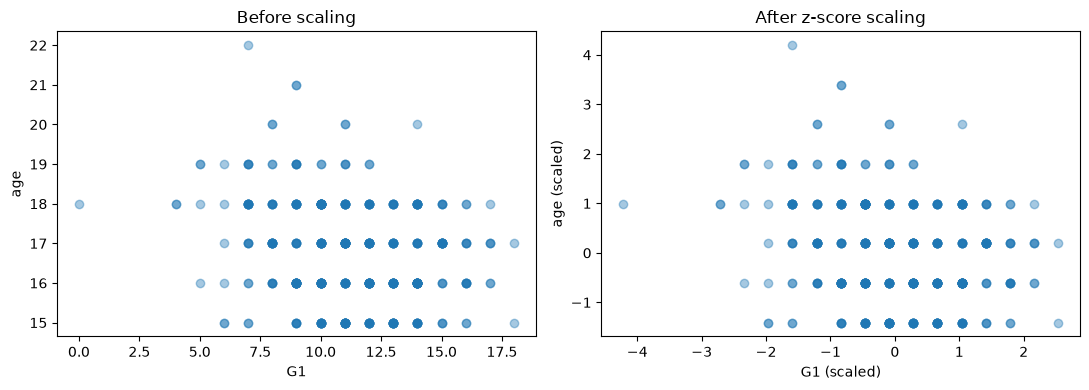

In [7]:
# Visualize the effect of scaling on two features with very different ranges
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(X_train[:, 0], X_train[:, 5], alpha=0.4)  # G1 vs age
axes[0].set_title("Before scaling")
axes[0].set_xlabel("G1")
axes[0].set_ylabel("age")

axes[1].scatter(X_train_norm[:, 0], X_train_norm[:, 5], alpha=0.4)
axes[1].set_title("After z-score scaling")
axes[1].set_xlabel("G1 (scaled)")
axes[1].set_ylabel("age (scaled)")

plt.tight_layout()
plt.show()

## 4. Cost function (vectorized)

Same squared-error cost as before, but now the prediction is a dot product over all features.

$$J(\vec{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)} \right)^2$$

`X @ w` computes all `m` predictions at once — that's the vectorized form of the loop you'd otherwise write.

In [8]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    f_wb = X @ w + b            # (m,) predictions for every example
    cost = np.sum((f_wb - y) ** 2) / (2 * m)
    return cost

## 5. Gradient (vectorized)

For multiple features the gradients are:

$$\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)} \right) x^{(i)}_j \qquad \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)} \right)$$

The `w` gradient is now a **vector** of length `n` (one partial derivative per feature). `X.T @ err` does the whole sum-over-examples for every feature in one matrix multiply.

In [9]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    err = (X @ w + b) - y       # (m,)
    dj_dw = (X.T @ err) / m     # (n,)  one gradient per feature
    dj_db = np.sum(err) / m     # scalar
    return dj_dw, dj_db

## 6. Gradient descent

Identical loop to the single-feature notebook — the only change is that `w` starts as a zero **vector** of length `n` instead of a single scalar.

In [10]:
def gradient_descent(X, y, alpha=0.01, iterations=1000):
    n = X.shape[1]
    w = np.zeros(n)            # vector now, not a scalar
    b = 0.0
    cost_history = []
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X, y, w, b))
    return w, b, cost_history

In [11]:
# Because features are scaled, we can use a much larger learning rate than 0.001
W, B, cost_history = gradient_descent(X_train_norm, Y_train, alpha=0.1, iterations=2000)

print("Learned weights (one per feature):")
for name, weight in zip(feature_cols, W):
    print(f"  {name:>10}: {weight:+.4f}")
print(f"\nBias b: {B:.4f}")
print(f"\nFirst cost: {cost_history[0]:.4f}   Final cost: {cost_history[-1]:.4f}")

Learned weights (one per feature):
          G1: +0.6047
          G2: +2.3852
   studytime: +0.0727
    failures: -0.0945
    absences: +0.1411
         age: +0.0321
        Medu: -0.1229
        Fedu: +0.0314

Bias b: 11.7972

First cost: 59.8826   Final cost: 0.8601


Because the features are scaled, the **magnitude of each weight is now comparable** — a bigger absolute weight roughly means that feature matters more for the prediction. (`G2` and `G1` should dominate, which makes sense: the earlier grades strongly predict the final grade.)

## 7. Learning curve

Cost should drop quickly and then flatten. If it ever goes *up* or oscillates, the learning rate is too large.

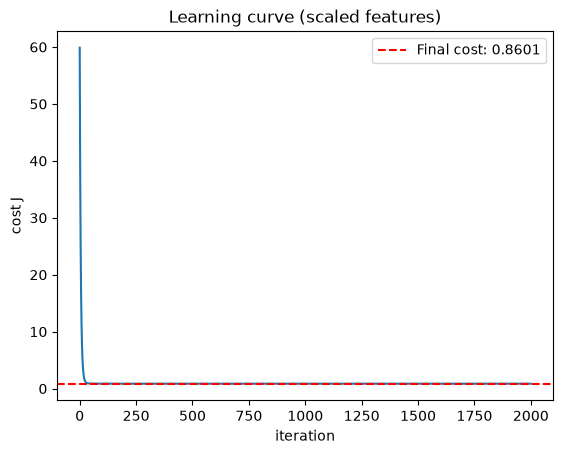

In [12]:
plt.plot(cost_history)
plt.axhline(y=cost_history[-1], color="red", linestyle="--",
            label=f"Final cost: {cost_history[-1]:.4f}")
plt.xlabel("iteration")
plt.ylabel("cost J")
plt.title("Learning curve (scaled features)")
plt.legend()
plt.show()

## 8. Evaluate on train vs test

In [13]:
train_cost = compute_cost(X_train_norm, Y_train, W, B)
test_cost = compute_cost(X_test_norm, Y_test, W, B)
print(f"Train cost: {train_cost:.4f}")
print(f"Test cost:  {test_cost:.4f}")

def r2_score(X, y, w, b):
    pred = X @ w + b
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

print(f"\nTrain R^2: {r2_score(X_train_norm, Y_train, W, B):.4f}")
print(f"Test  R^2: {r2_score(X_test_norm, Y_test, W, B):.4f}")

Train cost: 0.8601
Test cost:  0.6436

Train R^2: 0.8334
Test  R^2: 0.8778


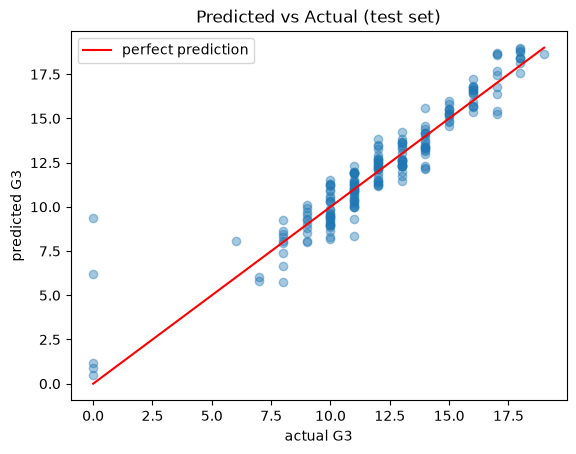

In [14]:
# Predicted vs actual on the test set. Perfect predictions lie on the red line.
test_pred = X_test_norm @ W + B
plt.scatter(Y_test, test_pred, alpha=0.4)
lims = [Y_test.min(), Y_test.max()]
plt.plot(lims, lims, color="red", label="perfect prediction")
plt.xlabel("actual G3")
plt.ylabel("predicted G3")
plt.title("Predicted vs Actual (test set)")
plt.legend()
plt.show()

## 9. Sanity check against scikit-learn

Our from-scratch weights should closely match `LinearRegression`. Small differences are just because gradient descent stopped at a finite number of iterations while sklearn solves it exactly.

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_norm, Y_train)

print("Comparison of weights:")
print(f"{'feature':>10} | {'ours':>10} | {'sklearn':>10}")
print("-" * 36)
for name, ours, skl in zip(feature_cols, W, model.coef_):
    print(f"{name:>10} | {ours:>+10.4f} | {skl:>+10.4f}")
print(f"{'bias':>10} | {B:>+10.4f} | {model.intercept_:>+10.4f}")

print(f"\nsklearn test R^2: {model.score(X_test_norm, Y_test):.4f}")

Comparison of weights:
   feature |       ours |    sklearn
------------------------------------
        G1 |    +0.6047 |    +0.6047
        G2 |    +2.3852 |    +2.3852
 studytime |    +0.0727 |    +0.0727
  failures |    -0.0945 |    -0.0945
  absences |    +0.1411 |    +0.1411
       age |    +0.0321 |    +0.0321
      Medu |    -0.1229 |    -0.1229
      Fedu |    +0.0314 |    +0.0314
      bias |   +11.7972 |   +11.7972

sklearn test R^2: 0.8778


## 10. Predict on a new student

To predict for a brand-new student, scale their raw feature values with the **same training `mu` and `sigma`**, then apply the model.

In [16]:
# Order must match feature_cols:
# [G1, G2, studytime, failures, absences, age, Medu, Fedu]
new_student = np.array([12, 13, 2, 0, 4, 17, 3, 2], dtype=float)

new_student_norm = zscore_normalize(new_student, mu, sigma)
predicted_g3 = new_student_norm @ W + B

print("Raw features:   ", dict(zip(feature_cols, new_student)))
print(f"\nPredicted final grade G3: {predicted_g3:.2f}")

Raw features:    {'G1': np.float64(12.0), 'G2': np.float64(13.0), 'studytime': np.float64(2.0), 'failures': np.float64(0.0), 'absences': np.float64(4.0), 'age': np.float64(17.0), 'Medu': np.float64(3.0), 'Fedu': np.float64(2.0)}

Predicted final grade G3: 13.28


## Recap — what changed vs single-feature regression

| | Single-feature | Multi-feature (this notebook) |
|---|---|---|
| input `x` | one column | matrix `X` of shape `(m, n)` |
| weight `w` | scalar | vector of length `n` |
| prediction | `w*x + b` | `X @ w + b` (dot product) |
| scaling | scaled one column | **z-score per feature** (`axis=0`) |
| learning rate | 0.001 | 0.1 (faster, thanks to scaling) |

**Key takeaways**
1. Vectorization lets the *same* cost/gradient code handle any number of features.
2. Feature scaling makes gradient descent converge far faster and makes the weights comparable.
3. Always fit the scaler (`mu`, `sigma`) on the training set and reuse it on test / new data.